In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [3]:
import matplotlib
print('matplotlib:', matplotlib.__version__)
import numpy
print('numpy:', numpy.__version__)
import scipy
print('scipy:', scipy.__version__)
import pandas 
print('pandas:', pandas.__version__)
import seaborn
print('seaborn:', seaborn.__version__)
import allensdk
print('allensdk:', allensdk.__version__)

matplotlib: 3.4.2
numpy: 1.22.0
scipy: 1.4.1
pandas: 1.5.3
seaborn: 0.12.2
allensdk: 2.16.2


In [4]:
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

In [5]:
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

### load experiments and cells tables

In [6]:
loading.get_platform_analysis_cache_dir()

'\\\\allen\\programs\\braintv\\workgroups\\nc-ophys\\visual_behavior\\platform_paper_cache_new'

In [ ]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = VisualBehaviorOphysProjectCache.from_local_cache(cache_dir=platform_cache_dir, use_static_cache=True)
experiments_table = cache.get_ophys_experiment_table()
print(len(experiments_table))

1936


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [8]:
# metadata tables
experiments_table = pd.read_csv(os.path.join(platform_cache_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# ### Define model version
# glm_version = '24_events_all_L2_optimize_by_session'
 
# # glm outputs
# run_params = pd.read_pickle(os.path.join(platform_cache_dir, 'glm_results', glm_version+'_run_params.pkl'))
# all_weights_df = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'weights_df.h5'), key='df')
# all_results = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'all_results.h5'), key='df')
# all_results_pivoted = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'results_pivoted.h5'), key='df')

# # # split out csid and oeid for results table
# # all_results['cell_specimen_id'] = [int(identifier.split('_')[1]) for identifier in all_results.identifier.values]
# # all_results['ophys_experiment_id'] = [int(identifier.split('_')[0]) for identifier in all_results.identifier.values]

# # # get results and weights just for platform paper experiments
# # results_pivoted = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'platform_results_pivoted.h5'), key='df')
# weights_df = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'platform_results_weights_df.h5'), key='df')
# results_pivoted = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'across_session_normalized_platform_results_pivoted.h5'), key='df')
# now drop ophys_experiment_id
# results_pivoted = results_pivoted.drop(columns=['ophys_experiment_id'])

# clustering results
# feature_matrix = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'clustering_feature_matrix.h5'), key='df')
# cluster_meta = pd.read_hdf(os.path.join(platform_cache_dir, 'glm_results', 'cluster_meta.h5'), key='df')

# get lists of matched cells and expts
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# get cre_lines and cell types for plot labels
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utilities.get_cell_types_dict(cre_lines, platform_experiments)


In [9]:
print(len(experiments_table.mouse_id.unique()), 'mice')
print(len(experiments_table.ophys_container_id.unique()), 'containers')
print(len(experiments_table.index.unique()), 'experiments')

107 mice
326 containers
1936 experiments


In [10]:
print(len(platform_experiments.mouse_id.unique()), 'mice')
print(len(platform_experiments.ophys_container_id.unique()), 'containers')
print(len(platform_experiments.index.unique()), 'experiments')

66 mice
134 containers
397 experiments


### get useful info

In [11]:
palette = utilities.get_experience_level_colors()

In [12]:
save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_figures_final\figure_2'

folder = 'population_activity'

## load multi_session_dfs 

In [13]:
data_type = 'events'

interpolate = True
output_sampling_rate = 30

inclusion_criteria = 'platform_experiment_table'

In [14]:
# params for stim response df creation
event_type = 'all'

# params for mean response df creation
conditions = ['cell_specimen_id', 'is_change']


change_suffix = '_'+utils.get_conditions_string(data_type, conditions)+'_'+inclusion_criteria

multi_session_df = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria, 
                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate, 
                                                         epoch_duration_mins=None)

# limit to changes, convert experience level and merge with cluster IDs
change_mdf = multi_session_df[multi_session_df.is_change==True]

# limit to non-changes, convert experience level and merge with cluster IDs
image_mdf = multi_session_df[(multi_session_df.is_change==False)]


# limit to platform paper expts
image_mdf = image_mdf[image_mdf.ophys_experiment_id.isin(platform_experiments.index.values)]
change_mdf = change_mdf[change_mdf.ophys_experiment_id.isin(platform_experiments.index.values)]


print(len(change_mdf.mouse_id.unique()), 'mice')
print(len(change_mdf.ophys_container_id.unique()), 'containers')
print(len(change_mdf.ophys_experiment_id.unique()), 'experiments')
print(len(change_mdf.cell_specimen_id.unique()), 'cells')


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


loading files from \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\multi_session_mean_response_dfs\interpolate_30Hz
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\multi_session_mean_response_dfs\interpolate_30Hz\mean_response_df_events_all_is_change_platform_experiment_table.pkl
there are 1881 experiments in the full multi_session_df


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 7 problematic experiments
there are 397 experiments in the multi_session_df after limiting to platform experiments
there are 397 experiments after filtering for inclusion criteria -  platform_experiment_table
66 mice
133 containers
393 experiments
14462 cells


In [15]:
# change_mdf['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in change_mdf.experience_level.values]

In [16]:
# params for stim response df creation
event_type = 'all'

# params for mean response df creation
conditions = ['cell_specimen_id', 'omitted']


change_suffix = '_'+utils.get_conditions_string(data_type, conditions)+'_'+inclusion_criteria

omission_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria, 
                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate, 
                                                         epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted==True]


print(len(omission_mdf.mouse_id.unique()), 'mice')
print(len(omission_mdf.ophys_container_id.unique()), 'containers')
print(len(omission_mdf.ophys_experiment_id.unique()), 'experiments')
print(len(omission_mdf.cell_specimen_id.unique()), 'cells')


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


loading files from \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\multi_session_mean_response_dfs\interpolate_30Hz
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved file at \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\multi_session_mean_response_dfs\interpolate_30Hz\mean_response_df_events_all_omitted_platform_experiment_table.pkl
there are 1879 experiments in the full multi_session_df


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 7 problematic experiments
there are 398 experiments in the multi_session_df after limiting to platform experiments
there are 398 experiments after filtering for inclusion criteria -  platform_experiment_table
66 mice
133 containers
398 experiments
14474 cells


### per image mdf

In [17]:
# %%time 

# # params for stim response df creation
# event_type = 'all'

# # params for mean response df creation
# conditions = ['cell_specimen_id', 'is_change', 'image_name']


# change_suffix = '_'+utils.get_conditions_string(data_type, conditions)+'_'+inclusion_criteria

# each_image_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria, 
#                                                         interpolate=interpolate, output_sampling_rate=output_sampling_rate, 
#                                                          epoch_duration_mins=None)


## Get reliable matched cells for each cre line

#### Save reliable matched cells for all cre lines

In [18]:
reliable_cells_omissions = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.10) & 
            (omission_mdf.mean_response > 0.05)]

reliable_cells_changes = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.10) & 
            (change_mdf.mean_response > 0.05)]

reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
print(len(reliable_cells))

reliable_change_containers = reliable_cells_changes.groupby(['ophys_container_id']).count()
reliable_change_containers = reliable_change_containers[reliable_change_containers.cell_specimen_id>3].reset_index()
reliable_change_containers['response_type'] = 'changes'

reliable_omission_containers = reliable_cells_omissions.groupby(['ophys_container_id']).count()
reliable_omission_containers = reliable_omission_containers[reliable_omission_containers.cell_specimen_id>3].reset_index()
reliable_omission_containers['response_type'] = 'omissions'

# reliable_containers_both = reliable_change_containers[reliable_change_containers.ophys_container_id.isin(reliable_omission_containers.ophys_container_id)]
reliable_containers_both = pd.concat([reliable_change_containers, reliable_omission_containers])

reliable_cells = reliable_cells[reliable_cells.ophys_container_id.isin(reliable_containers_both.ophys_container_id.unique())]
reliable_cells = reliable_cells[['cell_specimen_id', 'ophys_container_id', 'ophys_experiment_id']]
print(len(reliable_cells))

473
371


In [19]:
cache_dir = loading.get_platform_analysis_cache_dir()
reliable_cells.to_csv(os.path.join(cache_dir, 'reliable_matched_cells_omissions_and_changes.csv'))

##### Vip

In [20]:
cell_type = 'Vip Inhibitory'
# for cell_type in cell_types: 
event_type = 'omissions'
# get reliable cells for this cell type
reliable_cells_omissions = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.10) & 
            (omission_mdf.mean_response > 0.05) &
            (omission_mdf.cell_type==cell_type)]

reliable_cells_changes = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.10) & 
            (change_mdf.mean_response > 0.05) &
            (change_mdf.cell_type==cell_type)]

reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
vip_matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]
print(len(vip_matched_reliable_cells))

reliable_change_containers = reliable_cells_changes.groupby(['ophys_container_id']).count()
reliable_change_containers = reliable_change_containers[reliable_change_containers.cell_specimen_id>3].reset_index()

reliable_omission_containers = reliable_cells_omissions.groupby(['ophys_container_id']).count()
reliable_omission_containers = reliable_omission_containers[reliable_omission_containers.cell_specimen_id>3].reset_index()

reliable_containers_both = reliable_change_containers[reliable_change_containers.ophys_container_id.isin(reliable_omission_containers.ophys_container_id)]

vip_containers = reliable_containers_both.ophys_container_id.values

reliable_containers_both

137


,ophys_container_id,cell_specimen_id,is_change,mean_response,sem_response,mean_trace,sem_trace,trace_timestamps,mean_responses,mean_baseline,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
1,1018027859,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
2,1018027862,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10
3,1018028166,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
6,1022731527,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
7,1046576787,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6


In [21]:
# # Plot average omission responses for cells in each container

# cell_type = 'Vip Inhibitory'
# # for cell_type in cell_types: 
# event_type = 'omissions'


# for ophys_container_id in vip_containers:
#     cells_to_plot = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                     save_dir=save_dir, folder='reliable_example_cells', suffix='_'+str(ophys_container_id))

##### Sst

In [22]:
cell_type = 'Sst Inhibitory'

# get reliable cells for this cell type
reliable_cells_omissions = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.005) & 
            (omission_mdf.mean_response > 0.00) &
            (omission_mdf.cell_type==cell_type)]

reliable_cells_changes = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.10) & 
            (change_mdf.mean_response > 0.05) &
            (change_mdf.cell_type==cell_type)]

reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
sst_matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]
print(len(sst_matched_reliable_cells))

reliable_change_containers = reliable_cells_changes.groupby(['ophys_container_id']).count()
reliable_change_containers = reliable_change_containers[reliable_change_containers.cell_specimen_id>3].reset_index()

reliable_omission_containers = reliable_cells_omissions.groupby(['ophys_container_id']).count()
reliable_omission_containers = reliable_omission_containers[reliable_omission_containers.cell_specimen_id>=0].reset_index()

reliable_containers_both = reliable_change_containers[reliable_change_containers.ophys_container_id.isin(reliable_omission_containers.ophys_container_id)]

sst_containers = reliable_containers_both.ophys_container_id.values

reliable_containers_both

187


,ophys_container_id,cell_specimen_id,is_change,mean_response,sem_response,mean_trace,sem_trace,trace_timestamps,mean_responses,mean_baseline,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
0,1018028199,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
1,1018028202,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
2,1018028215,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,1074913336,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5


In [23]:
# # Plot average omission responses for cells in each container

# cell_type = 'Sst Inhibitory'
# # for cell_type in cell_types: 
# event_type = 'omissions'

# for ophys_container_id in sst_containers:
#     cells_to_plot = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
#     print(ophys_container_id, len(cells_to_plot))

#     pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                     save_dir=save_dir, folder='reliable_example_cells', suffix='_'+str(ophys_container_id))

##### Excitatory

In [24]:
# def get_fraction_matched_cells(matched_cells_table, platform_cells_table, conditions=['cell_type', 'ophys_container_id']):
#     total_cells = platform_cells_table.groupby(conditions).count()[['cell_specimen_id']].rename(columns={'cell_specimen_id': 'total_cells'})
#     matched_cells = matched_cells_table.groupby(conditions).count()[['cell_specimen_id']].rename(columns={'cell_specimen_id': 'matched_cells'})
#     fraction = total_cells.merge(matched_cells, on=conditions, how='left')  # need to use 'left' to prevent dropping of NaN values
#     # set sessions with no responsive cells (NaN) to zero
#     fraction['fraction_matched'] = fraction.matched_cells / fraction.total_cells
#     return fraction

In [25]:
# fraction_matched = ppf.get_fraction_matched_cells(matched_cells_table, platform_cells_table, conditions=['cell_type', 'ophys_container_id'])
# fraction_matched = fraction_matched.reset_index()
# fraction_matched = fraction_matched.merge(platform_experiments[['ophys_container_id', 'binned_depth', 'imaging_depth']], on='ophys_container_id')
# fraction_matched = fraction_matched.drop_duplicates(subset=['ophys_container_id'])

# well_matched_containers = fraction_matched[(fraction_matched.cell_type=='Excitatory') &
#                         (fraction_matched.binned_depth==175)].sort_values(by='fraction_matched', ascending=False).ophys_container_id.values
# well_matched_containers[:10]

In [26]:
cell_type = 'Excitatory'

# get reliable cells for this cell type
reliable_cells_omissions = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.001) & 
            (omission_mdf.mean_response > 0.00) &
            (omission_mdf.cell_type==cell_type)]

reliable_cells_changes = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.10) & 
            (change_mdf.mean_response > 0.1) &
            (change_mdf.cell_type==cell_type)]

reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
exc_matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]
print(len(exc_matched_reliable_cells))

reliable_change_containers = reliable_cells_changes.groupby(['ophys_container_id']).count()
reliable_change_containers = reliable_change_containers[reliable_change_containers.cell_specimen_id>3].reset_index()

reliable_omission_containers = reliable_cells_omissions.groupby(['ophys_container_id']).count()
reliable_omission_containers = reliable_omission_containers[reliable_omission_containers.cell_specimen_id>=0].reset_index()

reliable_containers_both = reliable_change_containers[reliable_change_containers.ophys_container_id.isin(reliable_omission_containers.ophys_container_id)]
reliable_containers_both

exc_containers = reliable_containers_both.ophys_container_id.values

reliable_containers_both

5512


,ophys_container_id,cell_specimen_id,is_change,mean_response,sem_response,mean_trace,sem_trace,trace_timestamps,mean_responses,mean_baseline,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
0,1018027657,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
1,1018027775,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
2,1018027784,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,1018027790,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6
4,1018028046,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
5,1079028117,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


In [27]:
# # Plot average omission responses for cells in each container

# cell_type = 'Excitatory'
# # for cell_type in cell_types: 
# event_type = 'omissions'

# for ophys_container_id in exc_containers:
#     cells_to_plot = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
#     print(ophys_container_id, len(cells_to_plot))
#     if len(cells_to_plot) > 2: 
#         pse.plot_reliable_example_cells(omission_mdf, cells_to_plot[:15], cell_type, event_type=event_type, 
#                                         save_dir=None, folder='reliable_example_cells', suffix='_'+str(ophys_container_id))

In [28]:
# # Plot average change responses for cells in each container 

# cell_type = 'Excitatory'
# # for cell_type in cell_types: 
# event_type = 'changes'

# for ophys_container_id in exc_containers:
#     cells_to_plot = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
#     print(ophys_container_id, len(cells_to_plot))
#     if len(cells_to_plot) > 2: 
#         pse.plot_reliable_example_cells(change_mdf, cells_to_plot[:15], cell_type, event_type=event_type, 
#                                         save_dir=save_dir, folder='reliable_example_cells', suffix='_'+str(ophys_container_id))

In [29]:
# # dataset_dict = {}
# for ophys_container_id in exc_containers: 
#     ophys_experiment_ids = platform_experiments[platform_experiments.ophys_container_id==ophys_container_id].sort_values(by='experience_level').index.values
#     figsize = (10, 3)
#     fig, ax = plt.subplots(1, 3, figsize=figsize)
#     # expts_dict = {}
#     for i,ophys_experiment_id in enumerate(ophys_experiment_ids): 
#         dataset = loading.get_ophys_dataset(ophys_experiment_id)
#         # expts_dict[ophys_experiment_id] = dataset
#         experience_level = platform_experiments.loc[ophys_experiment_id].experience_level
#         ax[i].imshow(dataset.max_projection, cmap='gray', vmin=0, vmax=np.percentile(dataset.max_projection, 98))
#         ax[i].axis('off')
#         ax[i].set_title(experience_level, color=experience_level_colors[i])
#     plt.suptitle(str(ophys_container_id))+'_'+utils.get_metadata_string(dataset.metadata), x=0.5, y=1.1)

## Save dataset dict for selected containers

In [30]:
# # manually selected based on having multiple cells in the main fig multi cell example averages
# Vip_containers = [1018027599, 1018027859, 1046576787, 1018027862, 1018028367]
# Sst_containers = [1018028339, 1018028135, 1018028202, 1018028153, 1074913336]
# Exc_containers = [1018027663, 1018027790, 1018028046, 1074922997, 1079028117, 1018027775,]

# # manually selected from the list above based on FOV matching quality
# manually_selected_ophys_containers = [1018027599, #Vip 1022731527
#                                         1018028339, #Sst
#                                         1018027775] #Exc 1079028117, 


# # full list of reliable matched cell containers
# print('vip:', list(vip_containers))
# print('sst:', list(sst_containers))
# print('exc:',list(exc_containers))

# full_list_of_reliable_ophys_containers = list(vip_containers)+list(sst_containers)+list(exc_containers)

# # manually selected from list of reliable matched cell containers based on traces & FOV match quality
# selected_reliable_ophys_containers = [1046576787, 1022731527, #Vip
#                                         1018028215, 1074913336, #Sst
#                                         1018027657, 1079028117,] #Exc # 1018028046, 1018027790, 1018027784, 1018027775] #Exc

# # automatically and maually selected set
# all_possible_containers = full_list_of_reliable_ophys_containers + manually_selected_ophys_containers


# # all possible containers
# all_containers = [1022731527, 1046576787, 1018027862, 1018027599, #Vip
#                     1018028199, 1018028215, 1018028202, 1018028339, #Sst 1074913336
#                     1079028117, 1018027657, 1018027775, 1018028046, 1018027790, 1018027784] # Exc


# # containers_dict = {'vip':[1022731527, 1018027599, 1046576787, 1018027859],
# #                     'sst': [1018028202, 1018028215, 1018028339, 1018028199] ,
# #                     'exc':[ 1018027775, 1079028117, 1018027790, 1018027657]}

# containers_dict = {'vip':[1022731527, 1046576787],
#                     'sst': [1018028202, 1018028215] ,
#                     'exc':[947838486, 1018027775]}


In [31]:
containers_dict = {'vip':[1022731527, 1046576787],
                    'sst': [1018028202, 1018028215] ,
                    'exc':[1018027825, 1018027775]}

In [32]:
# # Add exc containers to dataset dict 

# # for every possible container
# # ophys_container_ids = all_containers

# # for cell type specific containers
# ophys_container_ids = containers_dict['exc']

# # for well matched containers
# # ophys_container_ids = well_matched_containers[:5]

# # ophys_container_ids = [947838486, 1018027825, 1018027775]

# dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
#                                                             platform_experiments, 
#                                                             dataset_dict=None)


##### Plot matched ROI outlines

In [33]:
# def plot_max_intensity_projection(dataset, ax=None):
#     if ax is None:
#         fig, ax = plt.subplots()
#     max_projection = dataset.max_projection.data
#     ax.imshow(max_projection, cmap='gray', vmax=np.percentile(max_projection, 99))
#     ax.axis('off')
#     return ax

# def plot_roi_mask_outlines(dataset, cell_specimen_ids=None, ax=None):
#     if ax is None:
#         fig, ax = plt.subplots()
#     ax = plot_max_intensity_projection(dataset, ax=ax)
#     cell_specimen_table = dataset.cell_specimen_table.copy()
#     if cell_specimen_ids is None:
#         cell_specimen_ids = cell_specimen_table.index.values
#     if len(cell_specimen_table) > 0:
#         for cell_specimen_id in cell_specimen_ids:
#             mask = cell_specimen_table.loc[cell_specimen_id].roi_mask
#             ax.contour(mask, levels=0, colors=['red'], linewidths=[0.5])
#     ax.axis('off')
#     return ax

In [34]:
# ophys_container_id = ophys_containers[0]
# matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

# expt_ids = list(dataset_dict[ophys_container_id].keys())
# dataset = dataset_dict[ophys_container_id][expt_ids[0]]

# pse.plot_roi_mask_outlines(dataset, cell_specimen_ids=matched_cells, ax=None)

In [35]:
# ophys_experiment_id = 808621034
# dataset = loading.get_ophys_dataset(ophys_experiment_id)

# trials = dataset.trials.copy()
# start_times = trials[trials.is_change].start_time.values
# start_time = start_times[10]

# ppf.plot_behavior_and_physio_timeseries_stacked(dataset, start_time=628, duration_seconds=20, save_dir=save_dir, ax=None)

### Vip

In [36]:
# # Add Vip containers to dataset dict 

# ophys_container_ids = containers_dict['vip']

# dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
#                                                             platform_experiments, 
#                                                             dataset_dict=dataset_dict)



In [37]:

# # Plot matched max projection images for Vip

# ophys_containers = containers_dict['vip']

# for ophys_container_id in ophys_containers: 
#     pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
#                                                dataset_dict, save_dir=save_dir)


In [38]:
# # plot matched ROI outlines

# for ophys_container_id in ophys_container_ids: 
#     matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     pse.plot_max_and_roi_outlines_for_container(ophys_container_id, platform_experiments, 
#                                                 dataset_dict, cell_specimen_ids=matched_cells, save_dir=save_dir)

In [39]:
# # Plot cell example traces for Vip

# # ophys_container_ids = containers_dict['vip']

# for ophys_container_id in ophys_container_ids[:2]: 

#     matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     expt_ids = list(dataset_dict[ophys_container_id].keys())

#     for i, ophys_experiment_id in enumerate(expt_ids):
#         dataset = dataset_dict[ophys_container_id][ophys_experiment_id]

#         stim_presentations = dataset.stimulus_presentations.copy()
#         start_times = stim_presentations[stim_presentations.is_change].start_time.values

#         start_times = start_times[::10]
#         for s, start_time in enumerate(start_times): 
#             print(np.where(start_times==start_time)[0][0], 'out of', len(start_times))
#             pse.plot_single_cell_example_timeseries_and_behavior(dataset, start_time=start_time, duration_seconds=20, 
#                                                                 cell_specimen_ids=matched_cells, save_dir=save_dir, 
#                                                                 ax=None, suffix='')

### Sst

In [40]:
# # Add Sst containers to dataset dict 

# ophys_container_ids = containers_dict['sst']

# dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
#                                                             platform_experiments, 
#                                                             dataset_dict=dataset_dict)


In [41]:
# # Plot matched max projection images for Sst

# ophys_containers = containers_dict['sst']

# for ophys_container_id in ophys_containers: 
#     pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
#                                                dataset_dict, save_dir=save_dir)

In [42]:
# # for one container

# ophys_container_id = 1074913336

# dataset_dict = loading.get_dataset_dict_for_containers([ophys_container_id], 
#                                                             platform_experiments, 
#                                                             dataset_dict=dataset_dict)

# pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
#                                                dataset_dict, save_dir=save_dir)

In [43]:
# # plot matched ROI outlines

# for ophys_container_id in ophys_container_ids: 
#     matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     pse.plot_max_and_roi_outlines_for_container(ophys_container_id, platform_experiments, 
#                                                 dataset_dict, cell_specimen_ids=matched_cells, save_dir=save_dir)

In [44]:
# # Plot single cell examples for Sst

# ophys_container_ids = containers_dict['sst']

# for ophys_container_id in ophys_container_ids: 
#     matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     expt_ids = list(dataset_dict[ophys_container_id].keys())

#     for i, ophys_experiment_id in enumerate(expt_ids):
#         dataset = dataset_dict[ophys_container_id][ophys_experiment_id]

#         stim_presentations = dataset.stimulus_presentations.copy()
#         start_times = stim_presentations[stim_presentations.is_change].start_time.values

#         start_times = start_times[::10]
#         for s, start_time in enumerate(start_times): 
#             print(np.where(start_times==start_time)[0][0], 'out of', len(start_times))                                   
#             pse.plot_single_cell_example_timeseries_and_behavior(dataset, start_time=start_time, duration_seconds=20, 
#                                                                 cell_specimen_ids=matched_cells, save_dir=save_dir, 
#                                                                 ax=None, suffix='')

### Exc

In [45]:
# fraction_matched = ppf.get_fraction_matched_cells(matched_cells_table, platform_cells_table, conditions=['cell_type', 'ophys_container_id'])
# fraction_matched = fraction_matched.reset_index()
# fraction_matched = fraction_matched.merge(platform_experiments[['ophys_container_id', 'binned_depth', 'equipment_name']], on='ophys_container_id')
# fraction_matched = fraction_matched.drop_duplicates(subset=['ophys_container_id'])

# well_matched_containers = fraction_matched[(fraction_matched.cell_type=='Excitatory') &
#                         (fraction_matched.binned_depth==275) & 
#                         (fraction_matched.equipment_name.str.contains('MESO'))].sort_values(by='fraction_matched', ascending=False).ophys_container_id.values

In [46]:
# # Add Exc containers to dataset dict 

# ophys_container_ids = containers_dict['exc']

# ophys_container_ids = [1018028061, 1079028123, 1018028049, 1018027790, 1079028126, 1018028052, 1018027650]

# dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
#                                                             platform_experiments, 
#                                                             dataset_dict=dataset_dict)


In [47]:
# # Plot matched max projection images for Exc

# # ophys_container_ids = containers_dict['exc']
# ophys_container_ids = list(dataset_dict.keys())

# for ophys_container_id in ophys_container_ids: 
#     pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
#                                                dataset_dict, save_dir=save_dir)

In [48]:
# # plot matched ROI outlines

# # ophys_container_ids = containers_dict['exc']
# ophys_container_ids = list(dataset_dict.keys())

# for ophys_container_id in ophys_container_ids: 
#     matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     pse.plot_max_and_roi_outlines_for_container(ophys_container_id, platform_experiments, 
#                                                 dataset_dict, cell_specimen_ids=matched_cells, save_dir=save_dir)

In [49]:

# def get_high_snr_matched_cells_for_container(ophys_container_id, matched_cells_table, xlim_seconds=[500, 2500]):
#     matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

#     matched_high_snr_cells = []
#     ophys_experiment_ids = platform_experiments[platform_experiments.ophys_container_id==ophys_container_id].sort_values(by='experience_level').index.values
#     for i,ophys_experiment_id in enumerate(ophys_experiment_ids):
#         dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
#         ophys_timestamps = dataset.ophys_timestamps.copy()
#         dff_traces = dataset.dff_traces.copy()
#         cell_specimen_ids = ppf.sort_trace_csids_by_max_in_window(dff_traces, ophys_timestamps, xlim_seconds)
#         matched_cell_ids = [cell_id for cell_id in cell_specimen_ids if cell_id in matched_cells ]
#         if len(matched_cell_ids)>10:
#             matched_cell_ids = matched_cell_ids[:10]
#         matched_high_snr_cells = matched_high_snr_cells + matched_cell_ids
#     matched_high_snr_cells = np.unique(matched_high_snr_cells)

#     return matched_high_snr_cells

In [50]:
# sort by best matched cells across sessions 

ophys_container_ids = containers_dict['exc']

# other_exc_containers = [1018027663, 1018027790, 1018028046, 1074922997,]


# for ophys_container_id in ophys_container_ids: 

#     matched_cells_snr, dff_metrics = pse.get_high_snr_matched_cells_for_container(ophys_container_id, dataset_dict,
#                                              matched_cells_table, platform_experiments, xlim_seconds=[500, 2500])
    
#     # matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
#     matched_cells = exc_matched_reliable_cells[exc_matched_reliable_cells.ophys_container_id==ophys_container_id]
#     matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
#     matched_cells = matched_cells.drop_duplicates(subset='cell_specimen_id')
#     matched_cells = matched_cells.cell_specimen_id.values

#     expt_ids = list(dataset_dict[ophys_container_id].keys())

#     for i, ophys_experiment_id in enumerate(expt_ids):
#         dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
# # 
#         stim_presentations = dataset.stimulus_presentations.copy()
#         start_times = stim_presentations[stim_presentations.is_change].start_time.values

#         # start_times = start_times[::20]
#         start_times = np.arange(1500, 2000, 40)
#         for s, start_time in enumerate(start_times): 
#             print(np.where(start_times==start_time)[0][0], 'out of', len(start_times))
#             pse.plot_single_cell_example_timeseries_and_behavior(dataset, start_time=start_time, duration_seconds=20, 
#                                                                 cell_specimen_ids=matched_cells, save_dir=save_dir, 
#                                                                 sort_within_expt=False, dff_metrics=dff_metrics, 
#                                                                 ax=None, suffix='_matched')

In [51]:
# # within expt sorting

# ophys_container_ids = containers_dict['exc']

# # other_exc_containers = [1018027663, 1018027790, 1018028046, 1074922997,]
# ophys_container_ids = [1018027825]


# for ophys_container_id in ophys_container_ids: 

#     matched_cells, dff_metrics = pse.get_high_snr_matched_cells_for_container(ophys_container_id, dataset_dict,
#                                              matched_cells_table, platform_experiments, xlim_seconds=[500, 2500])
    
#     # matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
#     matched_cells = exc_matched_reliable_cells[exc_matched_reliable_cells.ophys_container_id==ophys_container_id]
#     matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
#     matched_cells = matched_cells.cell_specimen_id.values

#     expt_ids = list(dataset_dict[ophys_container_id].keys())

#     for i, ophys_experiment_id in enumerate(expt_ids):
#         dataset = dataset_dict[ophys_container_id][ophys_experiment_id]

#         stim_presentations = dataset.stimulus_presentations.copy()
#         start_times = stim_presentations[stim_presentations.is_change].start_time.values

#         # start_times = start_times[::15]
#         start_times = np.arange(500, 1000, 40)
#         for s, start_time in enumerate(start_times): 
#             print(np.where(start_times==start_time)[0][0], 'out of', len(start_times))
#             pse.plot_single_cell_example_timeseries_and_behavior(dataset, start_time=start_time, duration_seconds=20, 
#                                                                 cell_specimen_ids=matched_cells, save_dir=save_dir, 
#                                                                 sort_within_expt=False, dff_metrics=dff_metrics, 
#                                                                 ax=None, suffix='_matched')

## Combined plots for a specific container

In [52]:

cell_type = 'Excitatory'

n_reliable_cells_threshold = 5

reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
            (change_mdf.mean_response > 0.02) &
            (change_mdf.cell_type==cell_type) & 
            (change_mdf.ophys_experiment_id.isin(platform_experiments.index.unique()))]

# reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]


In [53]:
ophys_container_ids = [829561794]

dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
                                                            platform_experiments, 
                                                            dataset_dict=None)


833629926


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


834279496


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


835006071


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [54]:

ophys_container_id = 829561794

start_times = np.asarray([512])
duration_seconds = 18

matched_cells = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id]
matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
matched_cells = matched_cells.drop_duplicates(subset='cell_specimen_id')
matched_cells = matched_cells.cell_specimen_id.values
print(len(matched_cells))

5


0 out of 1


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_single_cell_examples.py:900: UserWarning: No contour levels were found within the data range.
  ax.contour(mask_data.roi_mask, levels=0, colors=roi_color, linewidths=[0.5])


using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided
saving


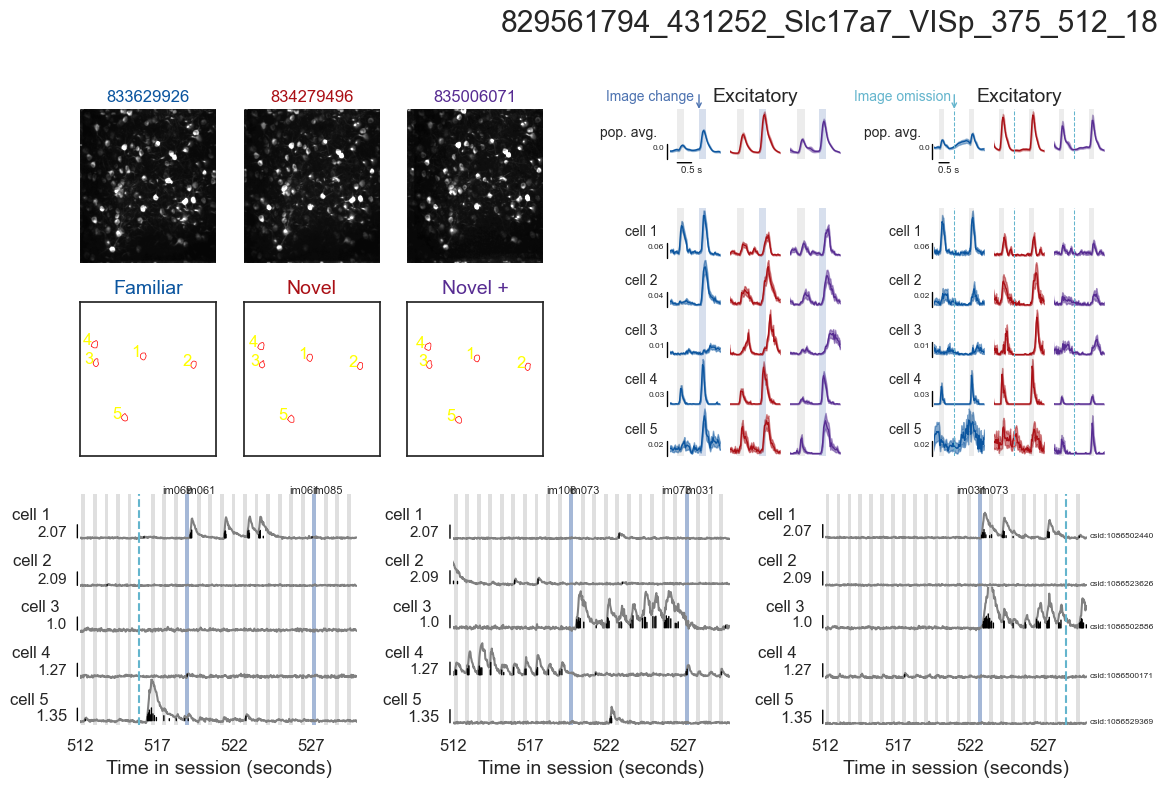

In [55]:

suffix = '_reliable_cells_selected'

pse.plot_matched_traces_across_sessions(ophys_container_id, dataset_dict, 
                                    matched_cells_table, platform_experiments, 
                                    change_mdf, omission_mdf, cell_type, skip_behavior=True,
                                    start_times=start_times, duration_seconds=duration_seconds,
                                    matched_cells=matched_cells, save_dir=save_dir, suffix=suffix)

In [56]:
# sessions = cache.get_ophys_session_table()

# sessions.to_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'ophys_sessions_table.csv'))

#### how many sessions has this mouse had before the first ophys expt in this plot?

In [138]:
platform_experiments[platform_experiments.ophys_container_id==ophys_container_id][['behavior_session_id', 'date_of_acquisition', 'mouse_id', 'experience_level', 
                                     'prior_exposures_to_image_set', 'prior_exposures_to_session_type', 'prior_exposures_to_omissions']]

,behavior_session_id,date_of_acquisition,mouse_id,experience_level,prior_exposures_to_image_set,prior_exposures_to_session_type,prior_exposures_to_omissions
ophys_experiment_id,,,,,,,
833629926,833100683,2019-03-06 10:25:48.396000+00:00,431252,Familiar,20,1,7
834279496,833946929,2019-03-07 10:50:35.644000+00:00,431252,Novel,0,0,8
835006071,834928595,2019-03-08 15:53:55.244000+00:00,431252,Novel +,1,1,9


In [139]:
behavior_sessions = cache.get_behavior_session_table()
print(len(behavior_sessions[(behavior_sessions.mouse_id=='431252')]), 'total sessions')
sessions = behavior_sessions[(behavior_sessions.mouse_id=='431252') & (behavior_sessions.date_of_acquisition<'2019-03-06 10:25:48.396000+00:00')]
print(len(sessions), 'prior to Familiar session')

38 total sessions
31 prior to Familiar session


In [140]:
# what area and depth is this FOV from?

platform_experiments[platform_experiments.ophys_container_id==ophys_container_id][['targeted_structure', 'imaging_depth', 'binned_depth']]

,targeted_structure,imaging_depth,binned_depth
ophys_experiment_id,,,
833629926,VISp,375,375
834279496,VISp,375,375
835006071,VISp,375,375


#### plot the ROI masks and print out how many cells there were

833629926 Familiar 97 matched cells,  161 total cells


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_single_cell_examples.py:900: UserWarning: No contour levels were found within the data range.
  ax.contour(mask_data.roi_mask, levels=0, colors=roi_color, linewidths=[0.5])


834279496 Novel 97 matched cells,  162 total cells
835006071 Novel + 97 matched cells,  146 total cells


array([<AxesSubplot:title={'center':'Familiar'}>,
       <AxesSubplot:title={'center':'Novel'}>,
       <AxesSubplot:title={'center':'Novel +'}>], dtype=object)

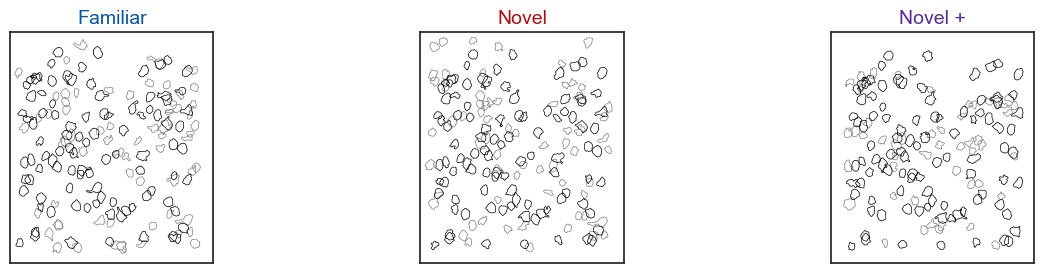

In [ ]:
pse.plot_matched_roi_outlines_for_container(ophys_container_id, platform_experiments, matched_cells_table,
                                            dataset_dict, cells_to_label=None, save_dir=None, ax=None)

0 out of 1


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_single_cell_examples.py:900: UserWarning: No contour levels were found within the data range.
  ax.contour(mask_data.roi_mask, levels=0, colors=roi_color, linewidths=[0.5])


using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided
saving


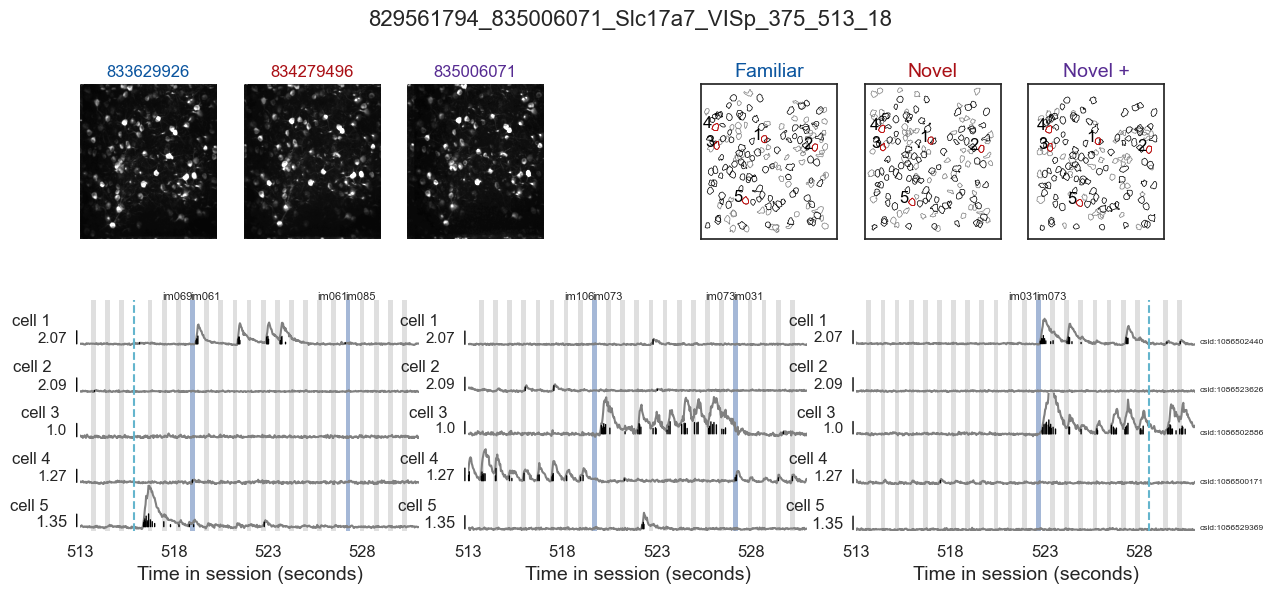

In [117]:
start_times = np.asarray([513])

pse.plot_matched_rois_and_traces_for_container(ophys_container_id, dataset_dict,
                                        matched_cells_table, platform_experiments, fontsize=12,
                                        start_times=start_times, duration_seconds=18,
                                        matched_cells=matched_cells, save_dir=save_dir, suffix='')

In [58]:
csids = [1086502440, 
         1086500171,
         1086502886,
         1086501666, 
         1086529369]

0 out of 1


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_single_cell_examples.py:900: UserWarning: No contour levels were found within the data range.
  ax.contour(mask_data.roi_mask, levels=0, colors=roi_color, linewidths=[0.5])


using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided
saving


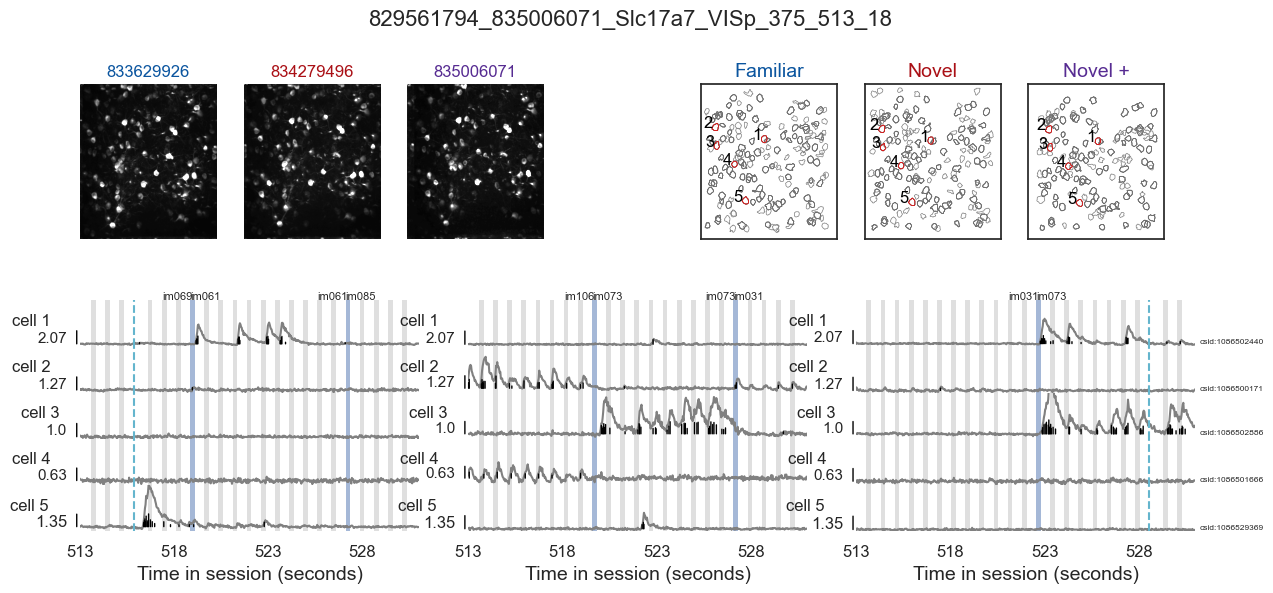

In [59]:
start_times = np.asarray([513])

csids = [1086502440, 
         1086500171,
         1086502886,
         1086501666, 
         1086529369]

pse.plot_matched_rois_and_traces_for_container(ophys_container_id, dataset_dict,
                                        matched_cells_table, platform_experiments, fontsize=12,
                                        start_times=start_times, duration_seconds=18,
                                        matched_cells=csids, save_dir=save_dir, suffix='')

## Generate combined plot for containers

In [60]:
# # sort by best matched cells across sessions 

# cell_type = 'Excitatory'

# n_reliable_cells_threshold = 5

# reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#             (change_mdf.mean_response > 0.02) &
#             (change_mdf.cell_type==cell_type) & 
#             (change_mdf.ophys_experiment_id.isin(platform_experiments.index.unique()))]

# # reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
# matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]

# containers = matched_reliable_cells.groupby('ophys_container_id').count().rename(columns={'cell_specimen_id': 'n_cells'})
# ophys_container_ids = containers[containers.n_cells>=n_reliable_cells_threshold].index.values
# len(ophys_container_ids)


#### Plot for many containers

In [61]:
# # Add containers to dataset dict 


# ophys_container_ids = ophys_container_ids[4:8]

# dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
#                                                             platform_experiments, 
#                                                             dataset_dict=None)


In [62]:

# duration_seconds = 20
# start_times = np.arange(500, 1100, 100)

# for ophys_container_id in ophys_container_ids: 

#     matched_cells = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id]
#     matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
#     matched_cells = matched_cells.drop_duplicates(subset='cell_specimen_id')
#     matched_cells = matched_cells.cell_specimen_id.values

#     suffix = '_high_snr_cells'

#     pse.plot_matched_traces_across_sessions(ophys_container_id, dataset_dict, 
#                                         matched_cells_table, platform_experiments, 
#                                         change_mdf, omission_mdf, cell_type,
#                                         start_times=start_times, duration_seconds=duration_seconds,
#                                         matched_cells=None, save_dir=save_dir, suffix=suffix)


## Select best containers

Based on visual inspection of traces (raw and average) plus FOV matching quality

In [63]:
containers_dict = {'vip':[1022731527, 1018027599, 1046576787, 1018027859],
                    'sst': [1018028202, 1018028215, 1018028339, 1018028199] ,
                    'exc':[ 1018027775, 1079028117, 1018027790, 1018027657]}

In [64]:
final_containers = {
    'vip': 1022731527,
    # 527 has big transients but good omisison responses, and is relatively well matched
    # 787 is ok, has omission in F, some N, noise in N+, has noise in one FOV
    # 599 has huge transients and is relatively well matched
    # 862 has sharp transients but few cells and poor matching, 
    # 859 FOV not super well matched, physio is good, super dramatic pupil changes
    'sst': 1018028202, 
    # 202 is best physiology wise but one of the FOVs is washed out, reasonably matched
    # 199 is washed out and has meh matching, responses are ok
    # 215 is ok physiology, one FOV is a little washed out but well matched
    # 339 is good but its 75um, FOVs look ok and are matched
    # 336 FOVs look bad, few cells
    'exc': 1018027775,
    # 775 FOVs look good, vessel on one side but dense and bright, activity is weirdly sparse, but maybe i picked the wrong cells
    # 117 is ok, not super well matched, big L5 cells, some good cells when all are plotted
    # 790 activity is meh, but maybe there are better cells, FOV looks ok, matching not perfect
    # 657 is sparse and not well matched, a couple of nice cells with novelty differences
    # 046 is sparse and not well matched, some ok traces but not many 
    # 784 sparse, not perfectly matched
    # 663 FOVs kinda ugly
    }

Other container options: 
* 1018027825 - reasonably well matched, traces are ok
* 947838486 - ok, not obviously well matched but not bad

## Single cell matched average response plots

In [65]:
cell_specimen_id = matched_cells_table.cell_specimen_id.unique()[0]


In [66]:
# cell_specimen_id = matched_cells_table.cell_specimen_id.unique()[0]

# ophys_container_id = matched_cells_table[matched_cells_table.cell_specimen_id==cell_specimen_id].ophys_container_id.values[0]


# ppf.plot_matched_roi_and_trace(ophys_container_id, cell_specimen_id, limit_to_last_familiar_second_novel=True,
#                                use_events=True, filter_events=False, save_figure=False)

In [67]:
# cell_specimen_id = matched_cells_table.cell_specimen_id.unique()[0]

# cell_metadata = matched_cells_table[matched_cells_table.cell_specimen_id==cell_specimen_id]

# ppf.plot_matched_roi_and_traces_example(cell_metadata, include_omissions=True,
#                                         use_events=True, filter_events=False, save_dir=None, folder=None)

### plot change response across sessions for cells in multi session df

In [68]:

cell_type = 'Excitatory'
# get reliable cells for this cell type
reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.2) & 
            (change_mdf.mean_response > 0.1) &
            (change_mdf.cell_type==cell_type)]
cells_to_plot = reliable_cells.cell_specimen_id.unique()
print(len(cells_to_plot))

# n_sessions = reliable_cells.groupby(['cell_specimen_id']).count()['is_change'].reset_index().rename(columns={'is_change': 'n_sessions'})
# cells_to_plot = n_sessions[n_sessions.n_sessions>=1].cell_specimen_id.unique()
# print(len(cells_to_plot))

28


In [69]:
n_sessions = reliable_cells.groupby(['cell_specimen_id']).count()['is_change'].reset_index().rename(columns={'is_change': 'n_sessions'})
cells_to_plot = n_sessions[n_sessions.n_sessions>=1].cell_specimen_id.unique()
print(len(cells_to_plot))

28


In [70]:

# def plot_reliable_example_cells(multi_session_mean_df, cells_to_plot, cell_type, event_type='changes', 
#                                 linewidth=2, save_dir=None, folder=None, suffix=''):
#     '''
#     Plot mean response for each experience level for a subset of cells that are reliably responsive
    
#     multi_session_mean_df: dataframe where each row is 1 cell in 1 session 
#                             and columns contain `mean_trace`, `sem_trace`, and `trace_timestamps` 
#     cells_to_plot: list of cell_specimen_ids of cells that are reliably responsive
#     cell_type: cell type of cells in cells_to_plot list, one of 'Excitatory', 'Sst Inhibitory', or 'Vip Inhibitory'
#     event_type: 'changes', 'omissions', or 'all

#     '''

#     if event_type == 'changes':
#         change = True
#         omitted = False
#         window = [-1, 1.5]
#     elif event_type == 'omissions':
#         change = False
#         omitted = True
#         window = [-1, 1.5]
#     else:
#         change = False
#         omitted = False
#         window = [-0.5, 0.75]

#     interval_sec = 1

#     sdf = multi_session_mean_df.copy()
#     experience_level_colors = utils.get_experience_level_colors()

#     # set this here so there is something to compare to for the first cell
#     last_container_id = sdf[(sdf.cell_specimen_id == cells_to_plot[0])].ophys_container_id.values[0]

#     n_cols = 4
#     figsize = (n_cols, (len(cells_to_plot)+2)/1.5)
#     fig, ax = plt.subplots(len(cells_to_plot)+2, n_cols, figsize=figsize, sharey='row')
#     ax = ax.ravel()

#     c = 0
#     for e, experience_level in enumerate(experience_levels): 
#         i = (c*n_cols)+e
#         color = experience_level_colors[e]
#         exp_data = sdf[(sdf.cell_type==cell_type) & (sdf.experience_level==experience_level)]
#         traces = exp_data.mean_trace.values
#         timestamps = exp_data.trace_timestamps.values[0]
#         ax[i] = utils.plot_mean_trace(traces, timestamps,
#                                     ylabel='', legend_label=None, color=color, linewidth=linewidth,
#                                     interval_sec=interval_sec, xlim_seconds=window, plot_sem=True, ax=ax[i])
#         ax[i] = utils.plot_flashes_on_trace(ax[i], timestamps, change=change, omitted=omitted, alpha=0.15, linewidth=0.75)
#         ax[i].set_xticklabels([])
#         ax[i].set_xlabel('')
#         ymin, ymax = ax[i].get_ylim()
#         ax[i].set_yticks([0, np.round(ymax*.3, 3)])
#         ax[i].set_yticklabels(['', np.round(ymax*.3, 3)], va='top')
#         if e == 0: 
#             ax[i].axvline(x=window[0]-0.1, ymin=0, ymax=0.3, color='k', linewidth=1, clip_on=False)
#         # if e == 0: 
#         #     left_tick = True
#         # else:
#         #     left_tick = False 
#         sns.despine(ax=ax[i], top=True, right=True, left=True, bottom=True)
#         ax[i].tick_params(bottom=False, left=False, right=False, top=False, labelsize=7, pad=-1)
#     ax[0].set_ylabel('pop. avg.', rotation=0, fontsize=10, ha='right', y=0.4)

#     for i in np.arange(3, 8): 
#         sns.despine(ax=ax[i], top=True, right=True, left=True, bottom=True)
#         ax[i].tick_params(bottom=False, left=False, right=False, top=False)
#         ax[i].axis('off')


#     for c, cell_specimen_id in enumerate(cells_to_plot):
#         ophys_container_id = sdf[(sdf.cell_specimen_id == cell_specimen_id)].ophys_container_id.values[0]
#         for e, experience_level in enumerate(experience_levels): 
#             i = ((c+2)*n_cols)+e
#             color = experience_level_colors[e]
#             cell_data = sdf[(sdf.cell_specimen_id == cell_specimen_id) & (sdf.experience_level==experience_level)]
#             if len(cell_data) > 0: # only plot if there is data for this exp level
#                 ax[i] = utils.plot_mean_trace_from_mean_df(cell_data, ylabel='', xlabel='', xlims=window,
#                                                         color=color, interval_sec=interval_sec, linewidth=linewidth,  ax=ax[i])
#                 ax[i] = utils.plot_flashes_on_trace(ax[i], cell_data.trace_timestamps.values[0],
#                                                             change=change, omitted=omitted, alpha=0.15, linewidth=0.75)
#                 ax[i].set_xticklabels([])
#             else: 
#                 ax[i].set_xticklabels([])
#             ax[i].set_xlabel('')
#             ymin, ymax = ax[i].get_ylim()
#             ax[i].set_yticks([0, np.round(ymax*.3, 2)])
#             ax[i].set_yticklabels(['', np.round(ymax*.3, 2)], va='top')
#             if e == 0: 
#                 ax[i].axvline(x=window[0]-0.1, ymin=0, ymax=0.3, color='k', linewidth=1, clip_on=False)
#                 ax[i].set_ylabel('cell '+str(c+1), rotation=0, fontsize=10, ha='right', y=0.4)
#             sns.despine(ax=ax[i], top=True, right=True, left=True, bottom=True)
#             ax[i].tick_params(bottom=False, left=False, right=False, top=False, labelsize=7, pad=-1, )
#         # ax[(i*n_cols)+3].set_title('csid:'+str(cell_specimen_id)+'\nocid:'+str(ophys_container_id), fontsize=6)
#         # 4th column with cell metadata
#         i = ((c+2)*n_cols)+3
#         if ophys_container_id != last_container_id: 
#             ylims = ax[i].get_ylim()
#             ax[i].axhline(y=ylims[1], xmin=0, xmax=1)
#             ax[i].set_xlim(0,1)
#             # ax[(i*n_cols)+3].set_ylim(0,2)
#         ax[i].text(s='csid:'+str(cell_specimen_id)+'\nocid:'+str(ophys_container_id), x=0, y=0, fontsize=8)
#         sns.despine(ax=ax[i], top=True, right=True, left=True, bottom=True)
#         ax[i].tick_params(bottom=False, left=False, right=False,  top=False)
#         ax[i].set_xticklabels([])
#         last_container_id = ophys_container_id
#     ax[1].set_title(cell_type, fontsize=14)

#     if save_dir: 
#         utils.save_figure(fig, figsize, save_dir, folder, cell_type.split(' ')[0]+'_'+event_type+suffix)

11


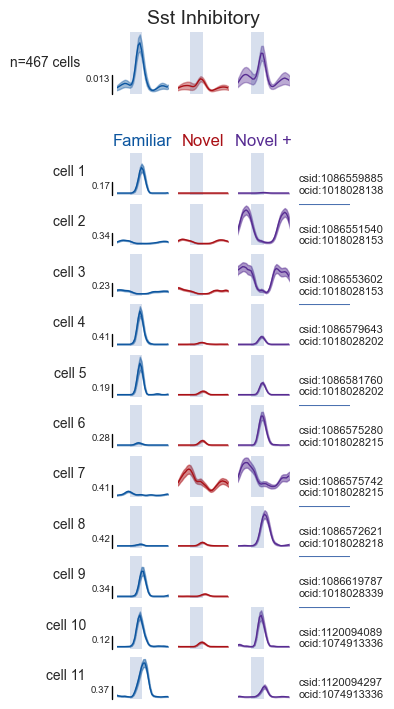

In [71]:
cell_type = 'Sst Inhibitory'

event_type = 'changes'
# get reliable cells for this cell type
reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
            (change_mdf.mean_response > 0.1) &
            (change_mdf.cell_type==cell_type)]
reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
cells_to_plot = reliable_cells.cell_specimen_id.unique()
print(len(cells_to_plot))

pse.plot_reliable_example_cells(change_mdf, cells_to_plot, cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

#### plot top responsive cells 

In [72]:
# cell_types = utils.get_cell_types()
# for cell_type in cell_types: 
#     event_type = 'changes'
#     # get reliable cells for this cell type
#     reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#                 (change_mdf.mean_response > 0.1) &
#                 (change_mdf.cell_type==cell_type)]
#     reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
#     cells_to_plot = reliable_cells.cell_specimen_id.unique()
#     print(len(cells_to_plot))

#     pse.plot_reliable_example_cells(change_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                     save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

In [73]:
# cell_types = utils.get_cell_types()
# for cell_type in cell_types: 
#     event_type = 'omissions'
#     # get reliable cells for this cell type
#     reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#                 (change_mdf.mean_response > 0.1) &
#                 (change_mdf.cell_type==cell_type)]
#     reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
#     cells_to_plot = reliable_cells.cell_specimen_id.unique()
#     print(len(cells_to_plot))

#     pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                     save_dir=save_dir, folder='reliable_example_cells', suffix='_matched_to_changes')

33


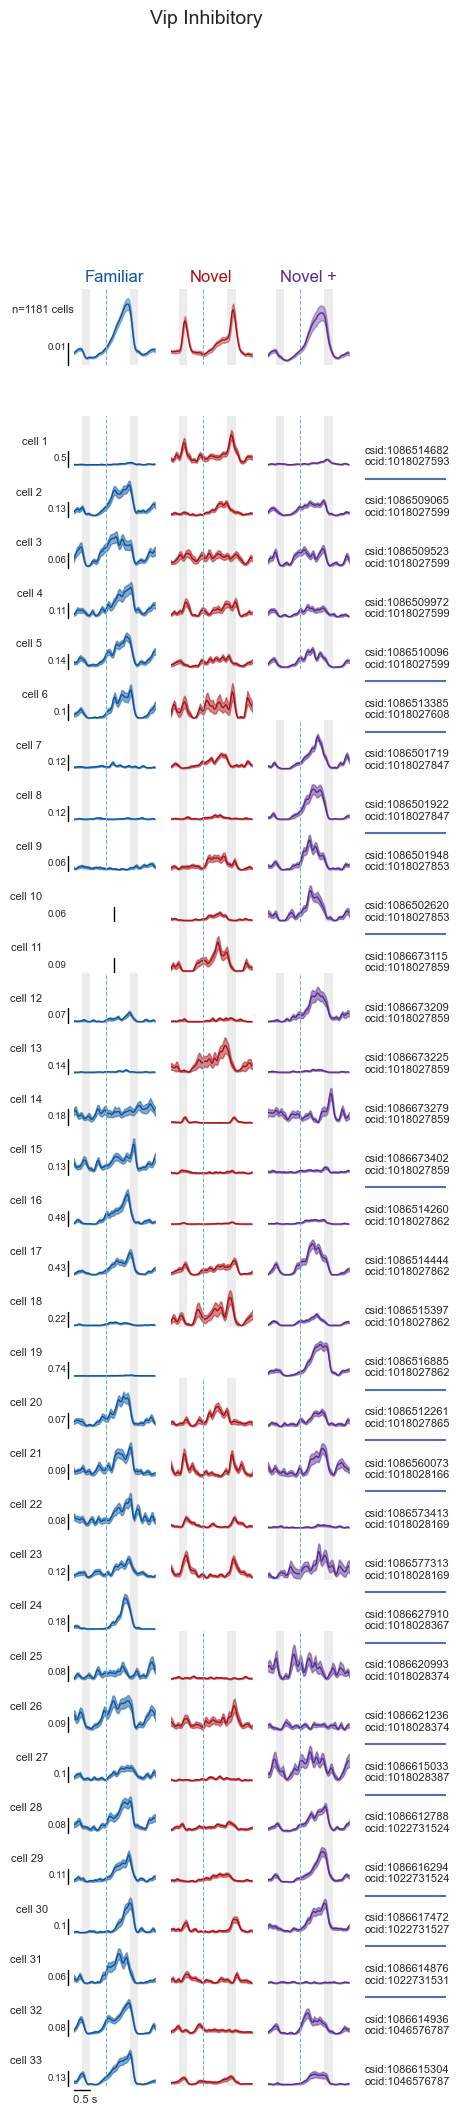

In [213]:
cell_types = utils.get_cell_types()
cell_type = 'Vip Inhibitory'
# for cell_type in cell_types: 
event_type = 'omissions'
# get reliable cells for this cell type
reliable_cells = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.15) & 
            (omission_mdf.mean_response > 0.1) &
            (omission_mdf.cell_type==cell_type)]
reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
cells_to_plot = reliable_cells.cell_specimen_id.unique()
print(len(cells_to_plot))

pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

#### plot selected cells

In [75]:
Vip_containers = [1018027599, 1018027859, 1046576787, 1018027862, 1018028367]

Sst_containers = [1018028339, 1018028135, 1018028202, 1018028153, 1074913336]

Exc_containers = [1018027663, 1018027790, 1018028046, 1074922997, 1079028117, 1018027775,]


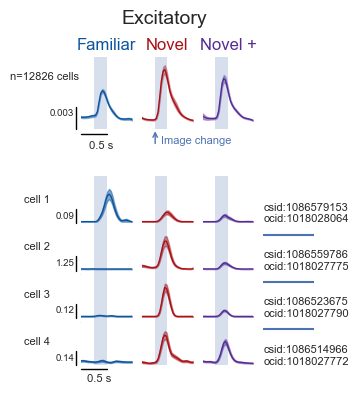

In [174]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


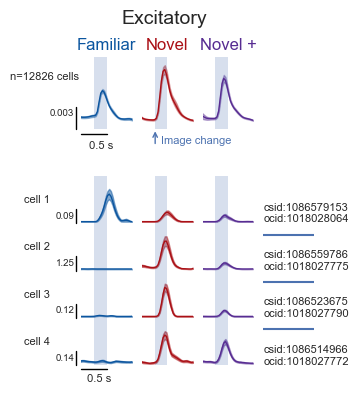

In [209]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


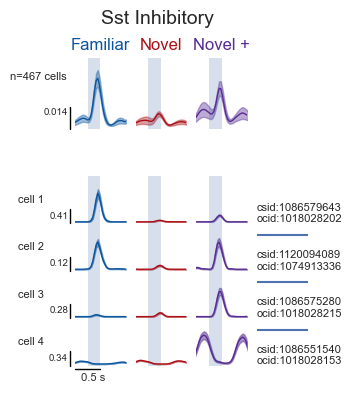

In [210]:
Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
                    # 1086559885, 1086619787, 1086553602, 1120094297]
#1086575742, ]
cell_type = 'Sst Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


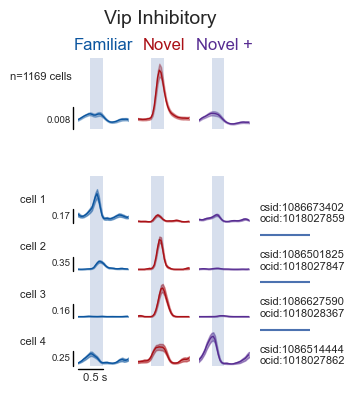

In [211]:

Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 
# 1086627395, 1086673073, 1086519532, 1086516885, 1086615418, ]
event_type='changes'
cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


### omissions

In [187]:
# Exc_omission_cells = [1086529704, 1086514606, 1086571711, 1120092455, 1120102262,  
#                       1086530117, 1120090879,  1086526518,]

# Sst_omission_cells = [ 1086559850, 1086569242, 1086551540, 1120094842, 1086619649, 
#                       1086620900,  1086575742,1086556653,]

# Vip_omission_cells = [1086615304, 1086617472, 1086514260, 1086516885,  1086514444, 
#                       1086614936 ,1086614349, 1086627910, 1086510096, 1086501719, 1086673225,  ]


# event_type = 'omissions'

# cell_type = 'Excitatory'
# pse.plot_reliable_example_cells(omission_mdf, Exc_omission_cells, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

# cell_type = 'Sst Inhibitory'
# pse.plot_reliable_example_cells(omission_mdf, Sst_omission_cells, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

# cell_type = 'Vip Inhibitory'
# pse.plot_reliable_example_cells(omission_mdf, Vip_omission_cells, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [188]:
8*1.5

12.0

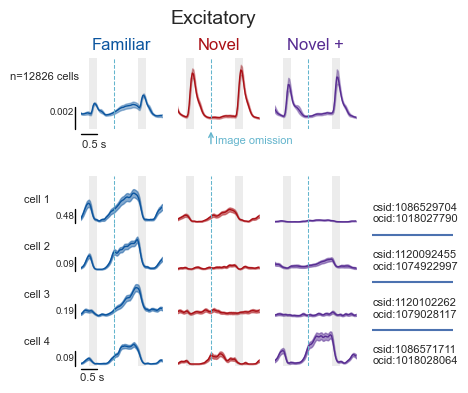

In [206]:
Exc_omission_cells = [ 1086529704, 1120092455, 1120102262, 1086571711,  1086514606, 
                      1086530117, 1120090879,  1086526518,]
event_type = 'omissions'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(omission_mdf, Exc_omission_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

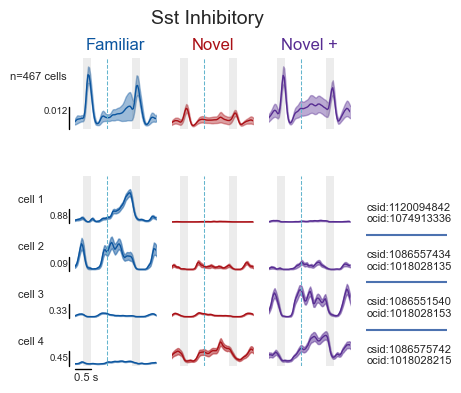

In [207]:
Sst_omission_cells = [1120094842,  1086557434, 1086551540, 1086575742, 1086569242, 
                     1086620900,  1086556653, 1086559850, 1086619649,]

event_type = 'omissions'

cell_type = 'Sst Inhibitory'
pse.plot_reliable_example_cells(omission_mdf, Sst_omission_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

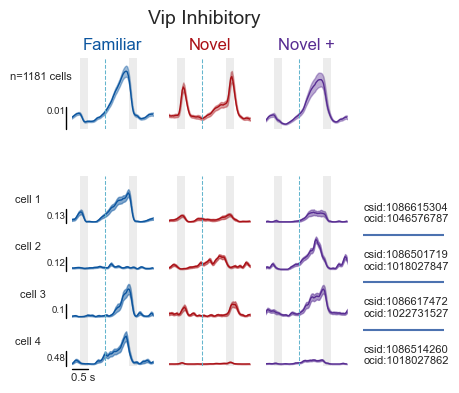

In [218]:
Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
                      1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]

# Vip_omission_cells = [1086615304, 1086618157, 1086617472, 1086616294, 1086509523, 1086627590, 
#                       1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]

event_type = 'omissions'

cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(omission_mdf, Vip_omission_cells[:4], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


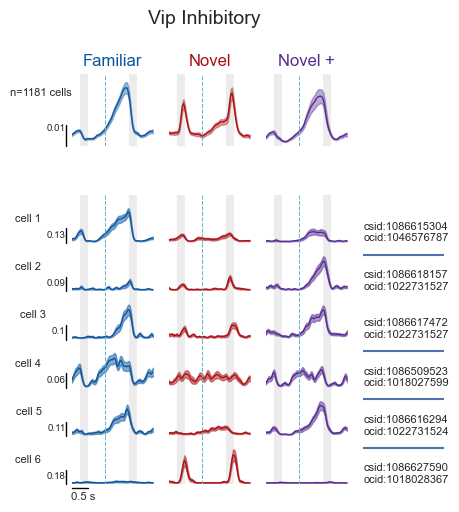

In [220]:
# Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
#                       1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]

Vip_omission_cells = [1086615304, 1086618157, 1086617472, 1086509523, 1086616294, 1086627590, 
                      1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]

event_type = 'omissions'

cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(omission_mdf, Vip_omission_cells[:6], cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected_2')


#### plot containers

In [85]:

# get relevant info for this cell
cell_metadata = cell_metadata.sort_values(by='experience_level')
cell_specimen_id = cell_metadata.cell_specimen_id.unique()[0]
ophys_container_id = cell_metadata.ophys_container_id.unique()[0]
ophys_experiment_ids = cell_metadata.ophys_experiment_id.unique()
n_expts = len(ophys_experiment_ids)


experience_levels = utils.get_experience_levels()
colors = utils.get_experience_level_colors()

figsize = (3 * n_cols, 3)
fig, ax = plt.subplots(1, n_cols, figsize=figsize)

print('cell_specimen_id:', cell_specimen_id)
print('ophys_container_id:', ophys_container_id)
for i, ophys_experiment_id in enumerate(ophys_experiment_ids):
    print('ophys_experiment_id:', ophys_experiment_id)
    experience_level = \
        cell_metadata[cell_metadata.ophys_experiment_id == ophys_experiment_id].experience_level.values[0]
    ind = experience_levels.index(experience_level)
    color = colors[ind]

    ct = dataset.cell_specimen_table.copy()
    cell_roi_id = ct.loc[cell_specimen_id].cell_roi_id
    ax[i] = sf.plot_cell_zoom(dataset.roi_masks, dataset.max_projection, cell_roi_id,
                                spacex=50, spacey=50, show_mask=True, ax=ax[i])
    ax[i].set_title(experience_level)

    # get change responses and plot on second to last axis
    window = [-1, 1.5]  # window around event
    sdf = loading.get_stimulus_response_df(dataset, time_window=window, interpolate=True,
                                            output_sampling_rate=30,
                                            data_type='events', event_type='changes',
                                            load_from_file=True)
    cell_data = sdf[(sdf.cell_specimen_id == cell_specimen_id) & (sdf.is_change == True)]

    ax[n_expts] = utils.plot_mean_trace(cell_data.trace.values, cell_data.trace_timestamps.values[0],
                                        ylabel=ylabel, legend_label=None, color=color, interval_sec=1,
                                        xlim_seconds=window, plot_sem=True, ax=ax[n_expts])
    ax[n_expts] = utils.plot_flashes_on_trace(ax[n_expts], cell_data.trace_timestamps.values[0],
                                                change=True, omitted=False)
    ax[n_expts].set_title('changes')


NameError: name 'cell_metadata' is not defined